In [1]:
%load_ext autoreload
%autoreload 2

import hydra
from hydra.core.global_hydra import GlobalHydra

GlobalHydra.instance().clear()
hydra.initialize(version_base=None, config_path="../conf")
cfg = hydra.compose(config_name="config")

from modules.visualization.plots import plot_positions, plot_pnl, plot_zscore
from modules.data_services.data_utils import load_strategy_result, load_btc_benchmark

interval = cfg.market.interval

test_start = cfg.performance.test.start
test_end = cfg.performance.test.end

In [2]:
ticker_x = "BTCUSDT"
ticker_y = "BCHUSDT"

result = load_strategy_result(file_name=f"test_{ticker_x}_{ticker_y}")

In [3]:
result.stats

,gross,net
total_return,0.1881,0.1605
cagr,6.5919,4.7564
volatility,0.0055,0.0055
volatility_annual,0.5136,0.5190
max_drawdown,-0.1740,-0.1837
win_count,15.0000,15.0000
lose_count,13.0000,13.0000
win_rate,0.5357,0.5357
max_win,0.1170,0.1165
max_lose,-0.0584,-0.0589


In [4]:
result.rolling_window

45

In [5]:
result.data

,BTCUSDT,BCHUSDT,z_score,beta,entry_thr,exit_thr,sl_thr,q_x,q_y,w_x,w_y,signal,position,total_return,total_fees,net_return,total_return_pct,net_return_pct
open_time,,,,,,,,,,,,,,,,,,
2024-03-01 00:00:00,61501.11,304.2,1.072400,1.0,1.446585,0.101943,NaN,0.000000,0.000000,NaN,NaN,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
2024-03-01 01:00:00,61214.35,306.1,0.330712,1.0,1.446585,0.101943,NaN,0.000000,0.000000,NaN,NaN,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
2024-03-01 02:00:00,60980.00,313.5,-0.195620,1.0,1.446585,0.101943,NaN,0.000000,0.000000,NaN,NaN,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
2024-03-01 03:00:00,61105.91,317.5,-1.485185,1.0,1.446585,0.101943,2.896263,0.818251,-157.480315,0.5,0.5,1.0,1.0,0.000000,50.000000,-50.000000,0.000000,-0.000500
2024-03-01 04:00:00,61524.09,315.1,-1.939012,1.0,1.446585,0.101943,2.896263,0.818251,-157.480315,0.5,0.5,1.0,1.0,-720.129151,50.000000,-770.129151,-0.007201,-0.007701
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-03-31 20:00:00,70840.00,680.5,-4.256636,1.0,1.446585,0.101943,8.300877,0.705816,-73.475386,0.5,0.5,1.0,1.0,18822.458433,2764.022394,16058.436039,0.188225,0.160584
2024-03-31 21:00:00,70856.00,678.8,-4.705510,1.0,1.446585,0.101943,8.300877,0.705816,-73.475386,0.5,0.5,1.0,1.0,18686.257223,2764.022394,15922.234829,0.186863,0.159222
2024-03-31 22:00:00,70970.00,680.8,-3.743751,1.0,1.446585,0.101943,8.300877,0.705816,-73.475386,0.5,0.5,1.0,1.0,18752.744979,2764.022394,15988.722585,0.187527,0.159887


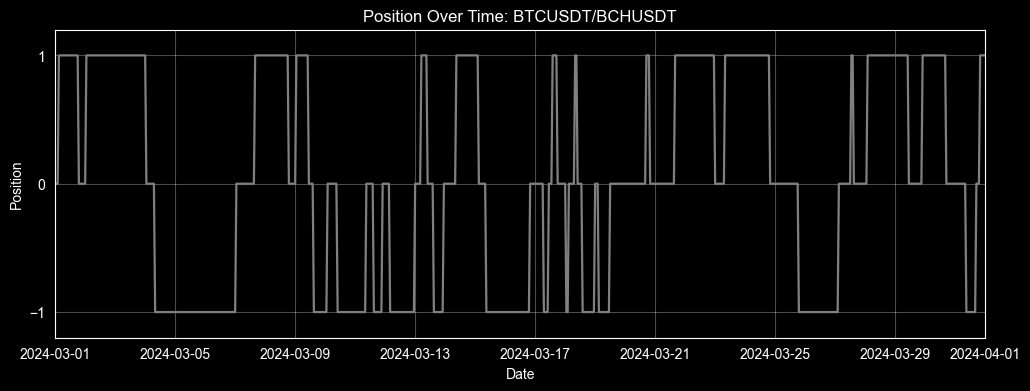

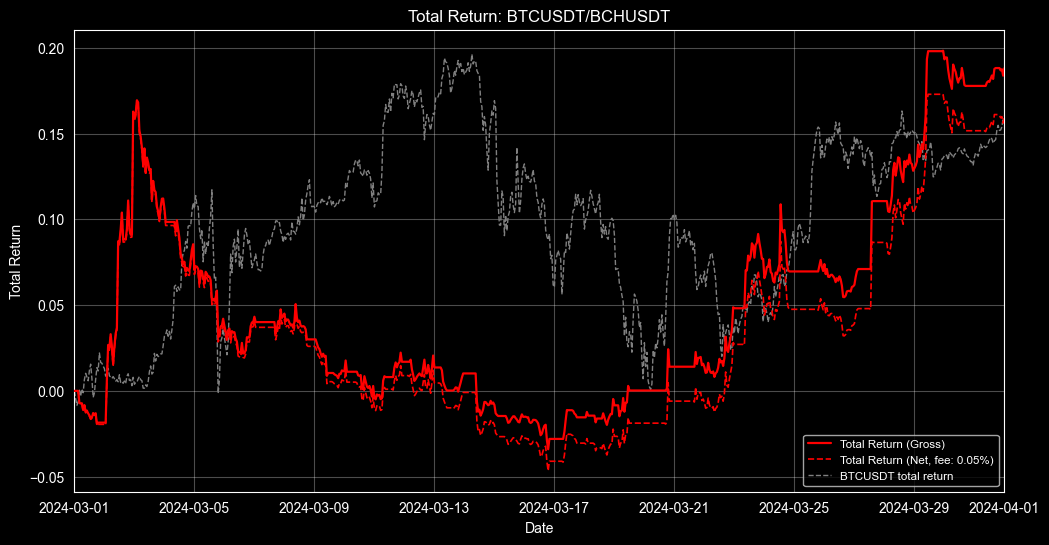

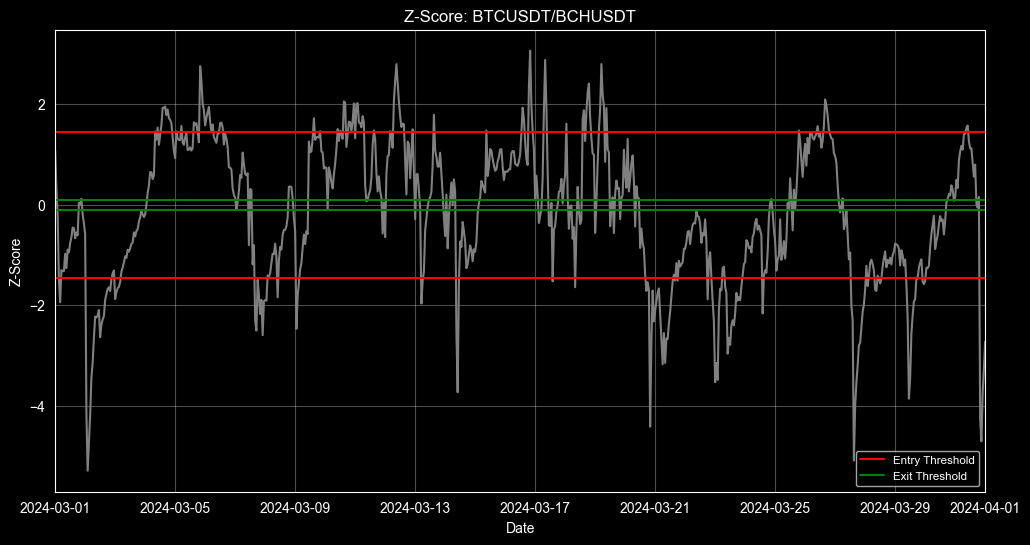

In [6]:
plot_positions(result, show=True)
btc_data = load_btc_benchmark(
    test_start=test_start,
    test_end=test_end,
    interval=interval,
)
plot_pnl(result, btc_data, show=True)
plot_zscore(result, show=True)